In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import shutil

# Copy entire dataset to Colab local disk (fast SSD)
LOCAL_BASE = "/content/processed_audio"

print("Copying from Drive to local disk...")
shutil.copytree(
    "/content/drive/MyDrive/Untitled_folder/processed_audio",
    LOCAL_BASE,
    dirs_exist_ok=True
)
print("✅ Copy done")

Copying from Drive to local disk...
✅ Copy done


In [3]:
import glob
import os
import pandas as pd

base_path = "/content/processed_audio"  # change this to your actual path

data = []

# Level 1 folders
level1_classes = ["stage2_cry", "stage1_not_cry"]

for lvl1 in level1_classes:
    lvl1_path = os.path.join(base_path, lvl1)

    # Get all subfolders (level 2)
    lvl2_classes = os.listdir(lvl1_path)

    for lvl2 in lvl2_classes:
        lvl2_path = os.path.join(lvl1_path, lvl2)

        # Get all audio files (adjust extension if needed)
        files = glob.glob(os.path.join(lvl2_path, "*.wav"))

        for file in files:
            data.append({
                "filepath": file,
                "label_lvl1": lvl1,
                "label_lvl2": lvl2
            })

df = pd.DataFrame(data)

print(df.head())
print("Total samples:", len(df))

                                            filepath  label_lvl1 label_lvl2
0  /content/processed_audio/stage2_cry/tired/tire...  stage2_cry      tired
1  /content/processed_audio/stage2_cry/tired/tire...  stage2_cry      tired
2  /content/processed_audio/stage2_cry/tired/tire...  stage2_cry      tired
3  /content/processed_audio/stage2_cry/tired/tire...  stage2_cry      tired
4  /content/processed_audio/stage2_cry/tired/tire...  stage2_cry      tired
Total samples: 4774


In [4]:
df["label_lvl1"].value_counts()

,count
label_lvl1,
stage2_cry,3808
stage1_not_cry,966


In [5]:
df["label_lvl2"].value_counts()

,count
label_lvl2,
hungry,1132
laugh,750
scared,698
belly_pain,631
tired,587
discomfort,543
burping,217
silence,108
noise,108


In [6]:
!pip install librosa

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import soundfile as sf
from tqdm import tqdm

durations = []

for path in tqdm(df["filepath"], desc="Processing audio files"):
    try:
        f = sf.SoundFile(path)
        duration = len(f) / f.samplerate
        durations.append(duration)
    except:
        durations.append(None)

df["duration_sec"] = durations

Processing audio files: 100%|██████████| 4774/4774 [00:00<00:00, 18500.43it/s]


In [8]:
df = df.dropna(subset=["duration_sec"])

In [9]:
avg_duration = df["duration_sec"].mean()
print(f"Average duration: {avg_duration:.2f} seconds")

Average duration: 4.32 seconds


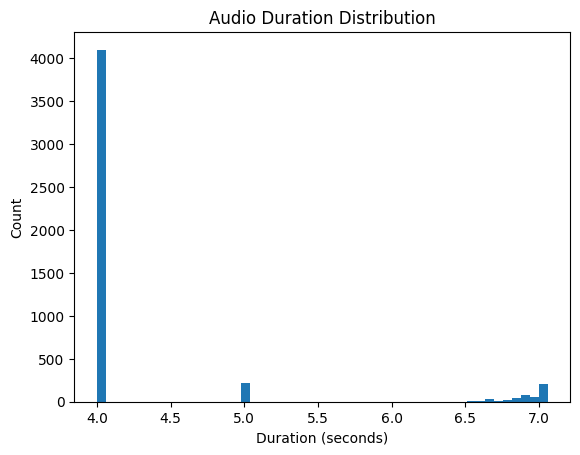

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["duration_sec"], bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio Duration Distribution")
plt.show()

In [11]:
df['duration_sec'].describe()

,duration_sec
count,4774.000000
mean,4.324888
std,0.869978
min,4.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,7.060000


In [12]:
!pip install librosa soundfile

import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [13]:
SR = 16000
DURATION = 4
SAMPLES = SR * DURATION

N_MFCC = 16
N_FFT = 800       # ~50 ms
HOP_LENGTH = 400  # ~25 ms

In [14]:
import pandas as pd

# Assume you already built df before
# Just convert to binary

df["label_binary"] = df["label_lvl1"].map({
    "stage2_cry": 1,
    "stage1_not_cry": 0
})

df = df.sample(frac=1).reset_index(drop=True)

print(df.head())

                                            filepath      label_lvl1  \
0  /content/processed_audio/stage2_cry/discomfort...      stage2_cry   
1  /content/processed_audio/stage2_cry/belly_pain...      stage2_cry   
2  /content/processed_audio/stage2_cry/tired/tire...      stage2_cry   
3  /content/processed_audio/stage1_not_cry/laugh/...  stage1_not_cry   
4  /content/processed_audio/stage2_cry/tired/tire...      stage2_cry   

   label_lvl2  duration_sec  label_binary  
0  discomfort           4.0             1  
1  belly_pain           4.0             1  
2       tired           4.0             1  
3       laugh           4.0             0  
4       tired           4.0             1  


In [15]:
import librosa
import numpy as np
from tqdm import tqdm

TARGET_SR = 16000
DURATION = 4
SAMPLES = TARGET_SR * DURATION

def extract_mfcc(path):
    try:
        audio, _ = librosa.load(path, sr=TARGET_SR)

        # normalize
        audio = audio / (np.max(np.abs(audio)) + 1e-6)

        # trim/pad
        if len(audio) > SAMPLES:
            audio = audio[:SAMPLES]
        else:
            audio = np.pad(audio, (0, SAMPLES - len(audio)))

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=TARGET_SR,
            n_mfcc=16,
            n_fft=800,
            hop_length=400
        )

        return mfcc

    except:
        return None

In [16]:
X = []
y = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting MFCC"):
    feat = extract_mfcc(row["filepath"])

    if feat is not None:
        X.append(feat)
        y.append(row["label_binary"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Extracting MFCC: 100%|██████████| 4774/4774 [00:55<00:00, 85.77it/s] 

X shape: (4774, 16, 161)
y shape: (4774,)


In [17]:
np.save("/content/X_mfcc.npy", X)
np.save("/content/y.npy", y)

In [18]:
X = X[..., np.newaxis]  # add channel

print(X.shape)

(4774, 16, 161, 1)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X.shape[1:]),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

In [22]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8806 - loss: 0.7446 - recall: 0.9304 - val_accuracy: 0.9351 - val_loss: 0.1855 - val_recall: 0.9528
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9283 - loss: 0.1735 - recall: 0.9590 - val_accuracy: 0.9455 - val_loss: 0.1398 - val_recall: 0.9869
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9571 - loss: 0.1152 - recall: 0.9757 - val_accuracy: 0.9623 - val_loss: 0.1061 - val_recall: 0.9764
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9688 - loss: 0.0865 - recall: 0.9813 - val_accuracy: 0.9728 - val_loss: 0.0880 - val_recall: 0.9856
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9754 - loss: 0.0643 - recall: 0.9859 - val_accuracy: 0.9749 - val_loss: 0.0754 - val_recall: 0.9751
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9801 - loss: 0.0512 - recall: 0.9875 - val_accuracy: 0.9759 - val_loss: 0.0755 - val_recall: 0.9948
Ep

In [23]:
model.evaluate(X_val, y_val)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9812 - loss: 0.0574 - recall: 0.9948


[0.05744733288884163, 0.981151819229126, 0.9947506785392761]

In [24]:
# ═══════════════════════════════════════════════════════════════════
# SAVE MODEL — run once after training
# ═══════════════════════════════════════════════════════════════════
model.save("/content/drive/MyDrive/Untitled_folder/baby_cry_model.keras")
print("✅ Model saved to Drive")

✅ Model saved to Drive


In [3]:
import os, glob, shutil
import soundfile as sf
import numpy as np
import librosa
from tqdm import tqdm

# ── Copy to local disk for speed ───────────────────────────────────
print("Copying test data to local disk...")
shutil.copytree(
    "/content/drive/MyDrive/Untitled_folder/Test_Data",
    "/content/test_data",
    dirs_exist_ok=True
)
TEST_DATA_DIR = "/content/test_data"
print("✅ Copy done")

# ── Convert .opus → .wav ───────────────────────────────────────────
opus_files = glob.glob(os.path.join(TEST_DATA_DIR, "*.opus"))
print(f"\nFound {len(opus_files)} .opus file(s) — converting...")

for opus_path in tqdm(opus_files, desc="Converting to WAV"):
    try:
        wav_path = opus_path.replace(".opus", ".wav")
        # ffmpeg is pre-installed on Colab
        os.system(f'ffmpeg -y -i "{opus_path}" -ar 16000 -ac 1 "{wav_path}" -loglevel quiet')
    except Exception as e:
        print(f"[SKIP] {opus_path} — {e}")

converted = glob.glob(os.path.join(TEST_DATA_DIR, "*.wav"))
print(f"✅ {len(converted)} WAV files ready")

Copying test data to local disk...
✅ Copy done

Found 7 .opus file(s) — converting...


Converting to WAV: 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]

✅ 7 WAV files ready


In [4]:
# ═══════════════════════════════════════════════════════════════════
# NEXT SESSION — start here (skip all training cells)
# ═══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import os, glob
from tqdm import tqdm

model = tf.keras.models.load_model("/content/drive/MyDrive/Untitled_folder/baby_cry_model.keras")
print("✅ Model loaded")

TARGET_SR   = 16000
SEGMENT_SEC = 4
SAMPLES     = TARGET_SR * SEGMENT_SEC
OVERLAP_SEC = 0.0
HOP_SAMPLES = SAMPLES - int(OVERLAP_SEC * TARGET_SR)
N_MFCC      = 16
N_FFT       = 800
HOP_LENGTH  = 400

# ── Segment & save ─────────────────────────────────────────────────
def split_and_save(wav_path, samples, hop, target_sr):
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    audio = audio.astype(np.float32)
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    audio = audio / (np.max(np.abs(audio)) + 1e-6)

    stem    = os.path.splitext(os.path.basename(wav_path))[0]
    out_dir = os.path.dirname(wav_path)

    saved, start, i = [], 0, 0
    while start < len(audio):
        seg = audio[start : start + samples]
        if len(seg) < samples:
            seg = np.pad(seg, (0, samples - len(seg)))
        out_path = os.path.join(out_dir, f"{stem}_seg{i:04d}.wav")
        sf.write(out_path, seg, target_sr)
        saved.append(out_path)
        start += hop
        i     += 1
    return saved

original_wavs = [
    p for p in
    glob.glob(os.path.join(TEST_DATA_DIR, "**", "*.wav"), recursive=True) +
    glob.glob(os.path.join(TEST_DATA_DIR, "*.wav"))
    if "_seg" not in os.path.basename(p)
]
print(f"Found {len(original_wavs)} original file(s)")

segment_paths = []
for wav_path in tqdm(original_wavs, desc="Segmenting & saving"):
    try:
        segment_paths.extend(split_and_save(wav_path, SAMPLES, HOP_SAMPLES, TARGET_SR))
    except Exception as e:
        print(f"[SKIP] {wav_path} — {e}")

print(f"✅ {len(segment_paths)} segments saved")

# ── Extract MFCCs ──────────────────────────────────────────────────
def extract_mfcc(path):
    try:
        audio, _ = librosa.load(path, sr=TARGET_SR)
        audio = audio / (np.max(np.abs(audio)) + 1e-6)
        if len(audio) > SAMPLES:
            audio = audio[:SAMPLES]
        else:
            audio = np.pad(audio, (0, SAMPLES - len(audio)))
        return librosa.feature.mfcc(
            y=audio, sr=TARGET_SR,
            n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
    except:
        return None

X_test, valid_paths = [], []
for path in tqdm(segment_paths, desc="Extracting MFCCs"):
    feat = extract_mfcc(path)
    if feat is not None:
        X_test.append(feat)
        valid_paths.append(path)

X_test = np.array(X_test)[..., np.newaxis]
print(f"X_test shape: {X_test.shape}")

# ── Predict ────────────────────────────────────────────────────────
probs = model.predict(X_test, batch_size=32).flatten()
preds = (probs >= 0.5).astype(int)

results = pd.DataFrame({
    "segment_path" : valid_paths,
    "cry_prob"     : probs.round(4),
    "prediction"   : preds,
    "label"        : ["cry" if p == 1 else "not_cry" for p in preds]
})

print(results.head(10))
print(f"\nCry segments    : {(preds == 1).sum()}")
print(f"Not-cry segments: {(preds == 0).sum()}")

# ── Per-file summary ───────────────────────────────────────────────
results["original_file"] = results["segment_path"].apply(
    lambda p: "_seg".join(os.path.basename(p).split("_seg")[:-1]) + ".wav"
)

summary = (
    results.groupby("original_file")
    .agg(
        total_segments = ("prediction", "count"),
        cry_segments   = ("prediction", "sum"),
        avg_cry_prob   = ("cry_prob",   "mean"),
    )
    .assign(cry_ratio = lambda d: d["cry_segments"] / d["total_segments"])
    .reset_index()
)
summary["file_verdict"] = summary["cry_ratio"].apply(
    lambda r: "cry" if r > 0.5 else "not_cry"
)

print("\n── Per-file summary ──────────────────────────────")
print(summary.to_string(index=False))

results.to_csv(os.path.join(TEST_DATA_DIR, "predictions.csv"), index=False)
summary.to_csv(os.path.join(TEST_DATA_DIR, "file_summary.csv"), index=False)
print(f"\n✅ Results saved to {TEST_DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded
Found 14 original file(s)


Segmenting & saving: 100%|██████████| 14/14 [00:00<00:00, 30.09it/s]


✅ 106 segments saved


Extracting MFCCs: 100%|██████████| 106/106 [00:15<00:00,  6.92it/s]


X_test shape: (106, 16, 161, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step
                                        segment_path  cry_prob  prediction  \
0  /content/test_data/AUD-20260501-WA0003_seg0000...    0.0746           0   
1  /content/test_data/AUD-20260501-WA0003_seg0001...    0.9376           1   
2  /content/test_data/AUD-20260501-WA0003_seg0002...    0.9321           1   
3  /content/test_data/AUD-20260501-WA0006_seg0000...    0.0002           0   
4  /content/test_data/AUD-20260501-WA0006_seg0001...    0.0000           0   
5  /content/test_data/AUD-20260501-WA0006_seg0002...    0.0000           0   
6  /content/test_data/AUD-20260501-WA0006_seg0003...    0.0000           0   
7  /content/test_data/AUD-20260501-WA0006_seg0004...    0.9994           1   
8  /content/test_data/AUD-20260501-WA0006_seg0005...    0.3376           0   
9  /content/test_data/AUD-20260501-WA0006_seg0006...    0.0000           0   

     label  
0  not_cry  
1      cry  
2      cry  
3  not_cry  
4  no

In [5]:
# ═══════════════════════════════════════════════════════════════════
# BUILD TEST DATAFRAME
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import os

# ── Segment-level results ──────────────────────────────────────────
test_df = pd.DataFrame({
    "segment_path"  : valid_paths,
    "original_file" : [
        "_seg".join(os.path.basename(p).split("_seg")[:-1]) + ".wav"
        for p in valid_paths
    ],
    "segment_index" : [
        int(os.path.basename(p).split("_seg")[-1].replace(".wav", ""))
        for p in valid_paths
    ],
    "cry_prob"      : probs.round(4),
    "prediction"    : preds,
    "label"         : ["cry" if p == 1 else "not_cry" for p in preds]
})

print("── Segment-level dataframe ───────────────────────────────")
print(test_df)
print(f"\nShape: {test_df.shape}")

# ── File-level summary ─────────────────────────────────────────────
file_df = (
    test_df.groupby("original_file")
    .agg(
        total_segments = ("prediction", "count"),
        cry_segments   = ("prediction", "sum"),
        avg_cry_prob   = ("cry_prob",   "mean"),
        max_cry_prob   = ("cry_prob",   "max"),
    )
    .assign(cry_ratio = lambda d: d["cry_segments"] / d["total_segments"])
    .reset_index()
)
file_df["verdict"] = file_df["cry_ratio"].apply(
    lambda r: "cry" if r > 0.5 else "not_cry"
)
file_df["avg_cry_prob"] = file_df["avg_cry_prob"].round(4)
file_df["max_cry_prob"] = file_df["max_cry_prob"].round(4)
file_df["cry_ratio"]    = file_df["cry_ratio"].round(4)

print("\n── File-level summary ────────────────────────────────────")
print(file_df.to_string(index=False))

# ── Save both to Drive ─────────────────────────────────────────────
DRIVE_OUT = "/content/drive/MyDrive/Untitled_folder/Test_Data"

test_df.to_csv(os.path.join(DRIVE_OUT, "segment_predictions.csv"), index=False)
file_df.to_csv(os.path.join(DRIVE_OUT, "file_predictions.csv"),    index=False)

print(f"\n✅ Saved to Drive:")
print(f"   {DRIVE_OUT}/segment_predictions.csv")
print(f"   {DRIVE_OUT}/file_predictions.csv")

── Segment-level dataframe ───────────────────────────────
                                          segment_path  \
0    /content/test_data/AUD-20260501-WA0003_seg0000...   
1    /content/test_data/AUD-20260501-WA0003_seg0001...   
2    /content/test_data/AUD-20260501-WA0003_seg0002...   
3    /content/test_data/AUD-20260501-WA0006_seg0000...   
4    /content/test_data/AUD-20260501-WA0006_seg0001...   
..                                                 ...   
101  /content/test_data/AUD-20260501-WA0005_seg0012...   
102  /content/test_data/AUD-20260501-WA0005_seg0013...   
103  /content/test_data/AUD-20260501-WA0005_seg0014...   
104  /content/test_data/AUD-20260501-WA0005_seg0015...   
105  /content/test_data/AUD-20260501-WA0005_seg0016...   

               original_file  segment_index  cry_prob  prediction    label  
0    AUD-20260501-WA0003.wav              0    0.0746           0  not_cry  
1    AUD-20260501-WA0003.wav              1    0.9376           1      cry  
2    AUD-2026

In [35]:
# ═══════════════════════════════════════════════════════════════════
# LOAD AND LISTEN TO TEST SAMPLES
# ═══════════════════════════════════════════════════════════════════
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output
import soundfile as sf
import os

# ── Build a quick summary per original file ────────────────────────
listen_df = file_df.copy()
listen_df = listen_df.sort_values("cry_ratio", ascending=False).reset_index(drop=True)

print("── Test Files Overview ───────────────────────────────────")
display(listen_df[["original_file", "total_segments", "cry_segments", "cry_ratio", "verdict"]])

# ── Interactive player ─────────────────────────────────────────────
print("\n── Interactive Listener ──────────────────────────────────")

file_options = listen_df["original_file"].tolist()

file_dropdown = widgets.Dropdown(
    options=file_options,
    description="File:",
    layout=widgets.Layout(width="500px")
)

seg_dropdown = widgets.Dropdown(
    description="Segment:",
    layout=widgets.Layout(width="500px")
)

play_btn   = widgets.Button(description="▶ Play",        button_style="primary")
play_all   = widgets.Button(description="▶ Play All Cry Segments", button_style="warning")
out        = widgets.Output()

def update_segments(change):
    fname = file_dropdown.value
    segs  = test_df[test_df["original_file"] == fname].sort_values("segment_index")
    seg_dropdown.options = [
        (f"seg {row.segment_index:04d} — {row.label} ({row.cry_prob:.2f})", row.segment_path)
        for _, row in segs.iterrows()
    ]

file_dropdown.observe(update_segments, names="value")
update_segments(None)  # init

def on_play(b):
    with out:
        clear_output()
        path = seg_dropdown.value
        if path and os.path.exists(path):
            audio, sr = sf.read(path)
            row = test_df[test_df["segment_path"] == path].iloc[0]
            print(f"📁 {os.path.basename(path)}")
            print(f"🔖 Label : {row.label.upper()}  |  Cry prob: {row.cry_prob:.4f}")
            display(Audio(audio, rate=sr, autoplay=True))
        else:
            print("File not found — make sure local segments still exist.")

def on_play_all_cry(b):
    with out:
        clear_output()
        fname    = file_dropdown.value
        cry_segs = test_df[
            (test_df["original_file"] == fname) & (test_df["prediction"] == 1)
        ].sort_values("segment_index")

        if cry_segs.empty:
            print(f"No cry segments found in {fname}")
            return

        print(f"🔊 {len(cry_segs)} cry segment(s) in {fname}\n")
        for _, row in cry_segs.iterrows():
            if os.path.exists(row.segment_path):
                audio, sr = sf.read(row.segment_path)
                print(f"  seg {row.segment_index:04d} — prob: {row.cry_prob:.4f}")
                display(Audio(audio, rate=sr, autoplay=False))

play_btn.on_click(on_play)
play_all.on_click(on_play_all_cry)

display(widgets.VBox([
    file_dropdown,
    seg_dropdown,
    widgets.HBox([play_btn, play_all]),
    out
]))

── Test Files Overview ───────────────────────────────────


,original_file,total_segments,cry_segments,cry_ratio,verdict
0,AUD-20260501-WA0002.wav,6,6,1.0000,cry
1,AUD-20260501-WA0001.wav,8,6,0.7500,cry
2,AUD-20260501-WA0003.wav,6,4,0.6667,cry
3,AUD-20260501-WA0005.wav,34,20,0.5882,cry
4,AUD-20260501-WA0000.wav,14,8,0.5714,cry
5,AUD-20260501-WA0006.wav,18,4,0.2222,not_cry
6,AUD-20260501-WA0007.wav,20,0,0.0000,not_cry



── Interactive Listener ──────────────────────────────────
